# Fraud Detection Analysis & Risk Interpretation

## Objective
Analyze credit card transaction data to identify patterns associated with fraudulent transactions, understand class imbalance, and develop machine learning models for fraud detection.

## Dataset
Credit Card Fraud Detection Dataset — Kaggle / ULB Machine Learning Group

## Project Focus
- Data understanding and preprocessing
- Exploratory Data Analysis
- Fraud pattern analysis
- Class imbalance
- Machine learning classification
- Model evaluation
- Business risk interpretation

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
import os

file_path = "../data/raw/creditcard.csv"

print("Exists:", os.path.exists(file_path))
print("Is file:", os.path.isfile(file_path))
print("Size (MB):", round(os.path.getsize(file_path) / (1024**2), 2))

Exists: True
Is file: True
Size (MB): 143.84


In [4]:
df = pd.read_csv("../data/raw/creditcard.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.shape

(284807, 31)

In [7]:
df.columns.tolist()
df.info()
df.isnull().sum().sum()
df["Class"].value_counts()
df["Class"].value_counts(normalize=True) * 100

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

Legitimate transactions: 284315
Fraudulent transactions: 492
Legitimate: 99.8273%
Fraud: 0.1727%


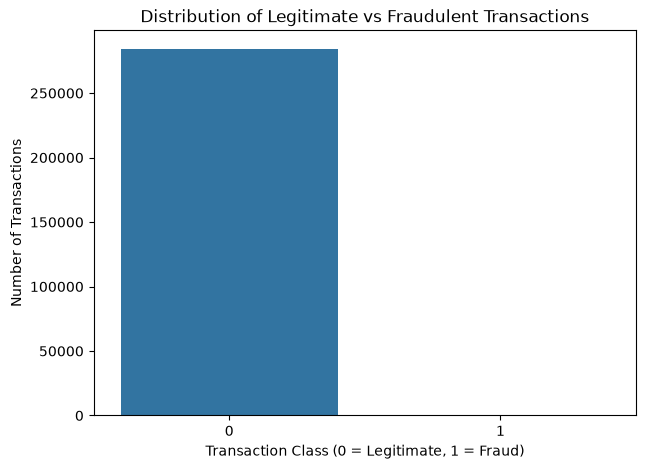

In [10]:
df.duplicated().sum()

class_counts = df["Class"].value_counts()

print("Legitimate transactions:", class_counts[0])
print("Fraudulent transactions:", class_counts[1])

class_percent = df["Class"].value_counts(normalize=True) * 100

print("Legitimate: {:.4f}%".format(class_percent[0]))
print("Fraud: {:.4f}%".format(class_percent[1]))

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Class")

plt.title("Distribution of Legitimate vs Fraudulent Transactions")
plt.xlabel("Transaction Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

In [11]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1081


In [12]:
df[["Time", "Amount", "Class"]].describe()

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


### Duplicate Records

A total of 1,081 duplicate rows were identified in the dataset. Duplicate records can bias exploratory analysis and machine learning models by giving repeated observations disproportionate influence.

These duplicate records will be removed before further analysis to maintain data quality and avoid potential leakage.

In [13]:
df = df.drop_duplicates().copy()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (283726, 31)


In [14]:
class_counts = df["Class"].value_counts()

print("Legitimate transactions:", class_counts[0])
print("Fraudulent transactions:", class_counts[1])

print("\nFraud percentage:",
      round((class_counts[1] / len(df)) * 100, 4), "%")

Legitimate transactions: 283253
Fraudulent transactions: 473

Fraud percentage: 0.1667 %


In [15]:
df[["Time", "Amount", "Class"]].describe()

,Time,Amount,Class
count,283726.000000,283726.000000,283726.000000
mean,94811.077600,88.472687,0.001667
std,47481.047891,250.399437,0.040796
min,0.000000,0.000000,0.000000
25%,54204.750000,5.600000,0.000000
50%,84692.500000,22.000000,0.000000
75%,139298.000000,77.510000,0.000000
max,172792.000000,25691.160000,1.000000


In [16]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


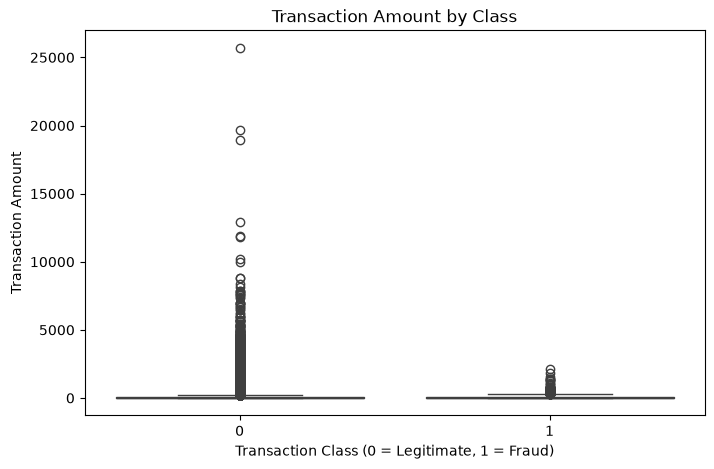

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Class", y="Amount")

plt.title("Transaction Amount by Class")
plt.xlabel("Transaction Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

In [19]:
df["Log_Amount"] = np.log1p(df["Amount"])

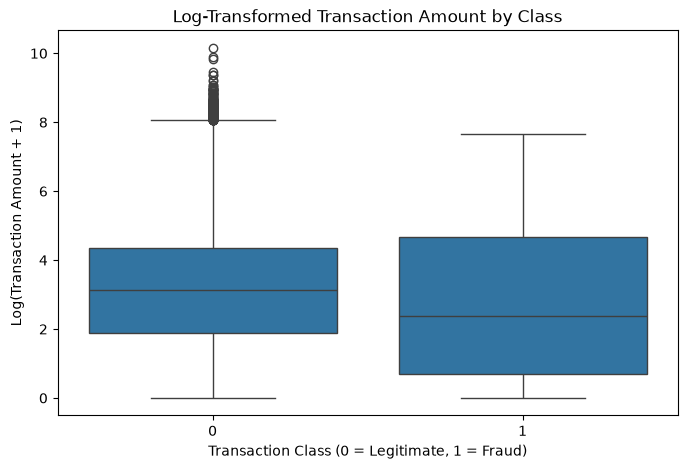

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Class", y="Log_Amount")

plt.title("Log-Transformed Transaction Amount by Class")
plt.xlabel("Transaction Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Log(Transaction Amount + 1)")

plt.show()

In [21]:
df.groupby("Class")["Amount"].agg(["mean", "median", "std", "min", "max"])

,mean,median,std,min,max
Class,,,,,
0,88.413575,22.00,250.379023,0.0,25691.16
1,123.871860,9.82,260.211041,0.0,2125.87


In [22]:
df.groupby("Class")["Amount"].describe()
df.groupby("Class")["Amount"].agg(["mean", "median", "std", "min", "max"])

,mean,median,std,min,max
Class,,,,,
0,88.413575,22.00,250.379023,0.0,25691.16
1,123.871860,9.82,260.211041,0.0,2125.87


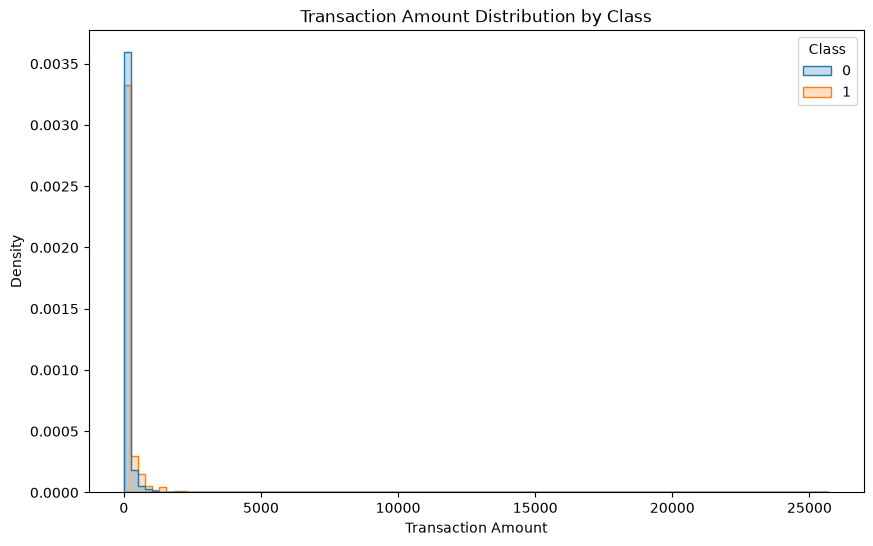

In [23]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=100,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")

plt.show()

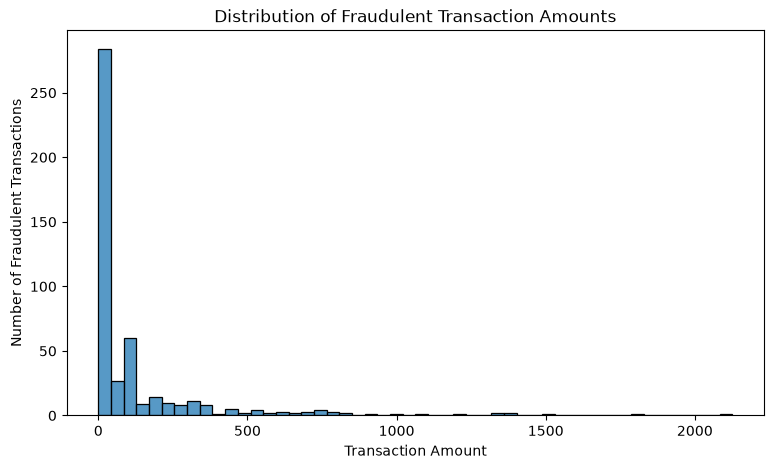

In [24]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df[df["Class"] == 1],
    x="Amount",
    bins=50
)

plt.title("Distribution of Fraudulent Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Fraudulent Transactions")

plt.show()

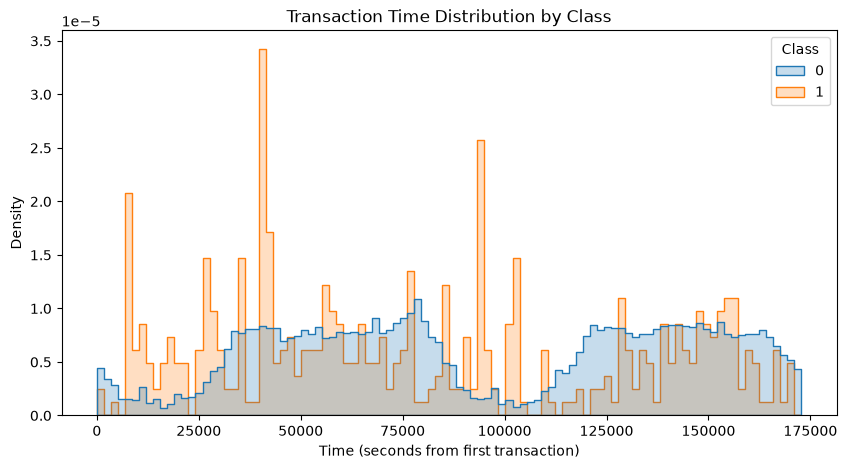

In [25]:
df.groupby("Class")["Time"].describe()

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=100,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("Transaction Time Distribution by Class")
plt.xlabel("Time (seconds from first transaction)")
plt.ylabel("Density")

plt.show()

In [28]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [27]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

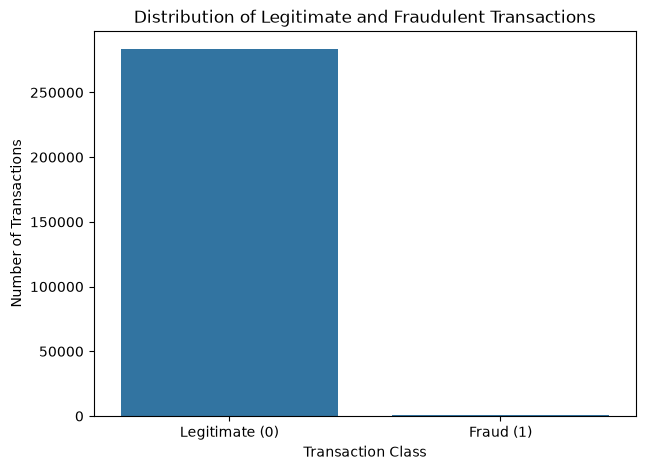

In [29]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Class")

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.xticks([0, 1], ["Legitimate (0)", "Fraud (1)"])

plt.show()

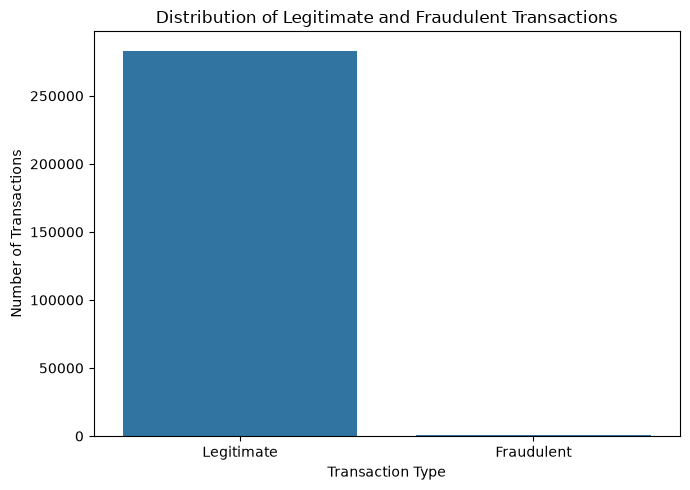

In [30]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(data=df, x="Class")

ax.set_title("Distribution of Legitimate and Fraudulent Transactions")
ax.set_xlabel("Transaction Type")
ax.set_ylabel("Number of Transactions")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Legitimate", "Fraudulent"])

plt.tight_layout()
plt.show()

In [31]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


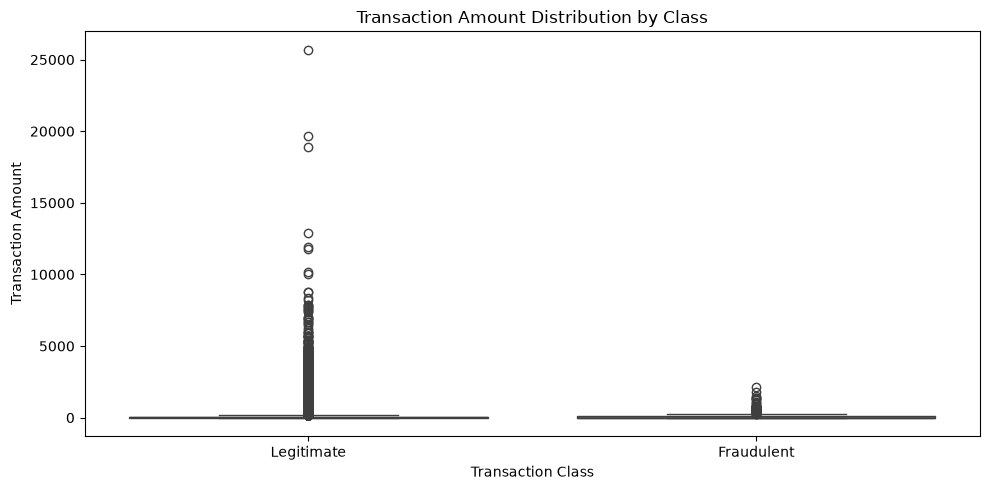

In [32]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")

plt.xticks([0, 1], ["Legitimate", "Fraudulent"])

plt.tight_layout()
plt.show()

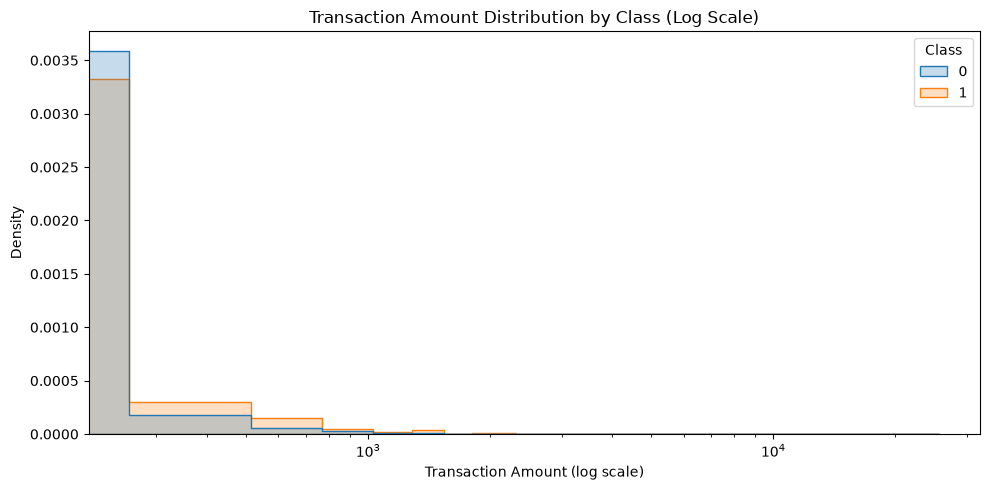

In [33]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=100,
    element="step",
    stat="density",
    common_norm=False
)

plt.xscale("log")

plt.title("Transaction Amount Distribution by Class (Log Scale)")
plt.xlabel("Transaction Amount (log scale)")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

In [34]:
df.groupby("Class")[["V1", "V2", "V3", "V4", "V5"]].mean()

,V1,V2,V3,V4,V5
Class,,,,,
0,0.013439,-0.009829,0.012853,-0.010440,0.006769
1,-4.498280,3.405965,-6.729599,4.472591,-2.957197


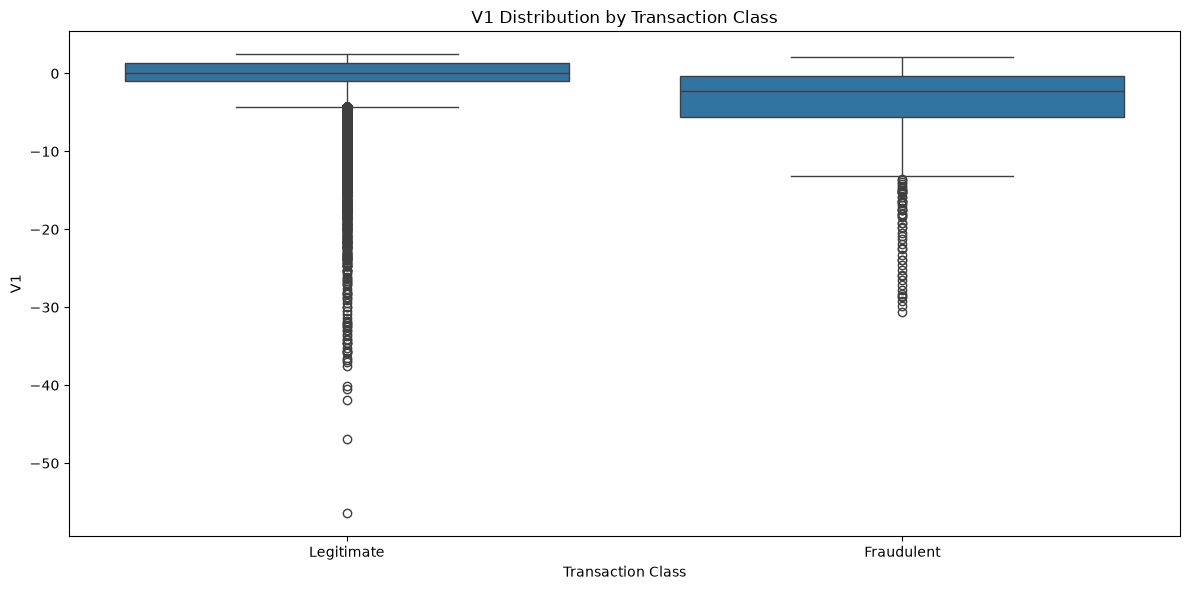

In [35]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Class",
    y="V1"
)

plt.title("V1 Distribution by Transaction Class")
plt.xlabel("Transaction Class")
plt.ylabel("V1")

plt.xticks([0, 1], ["Legitimate", "Fraudulent"])

plt.tight_layout()
plt.show()

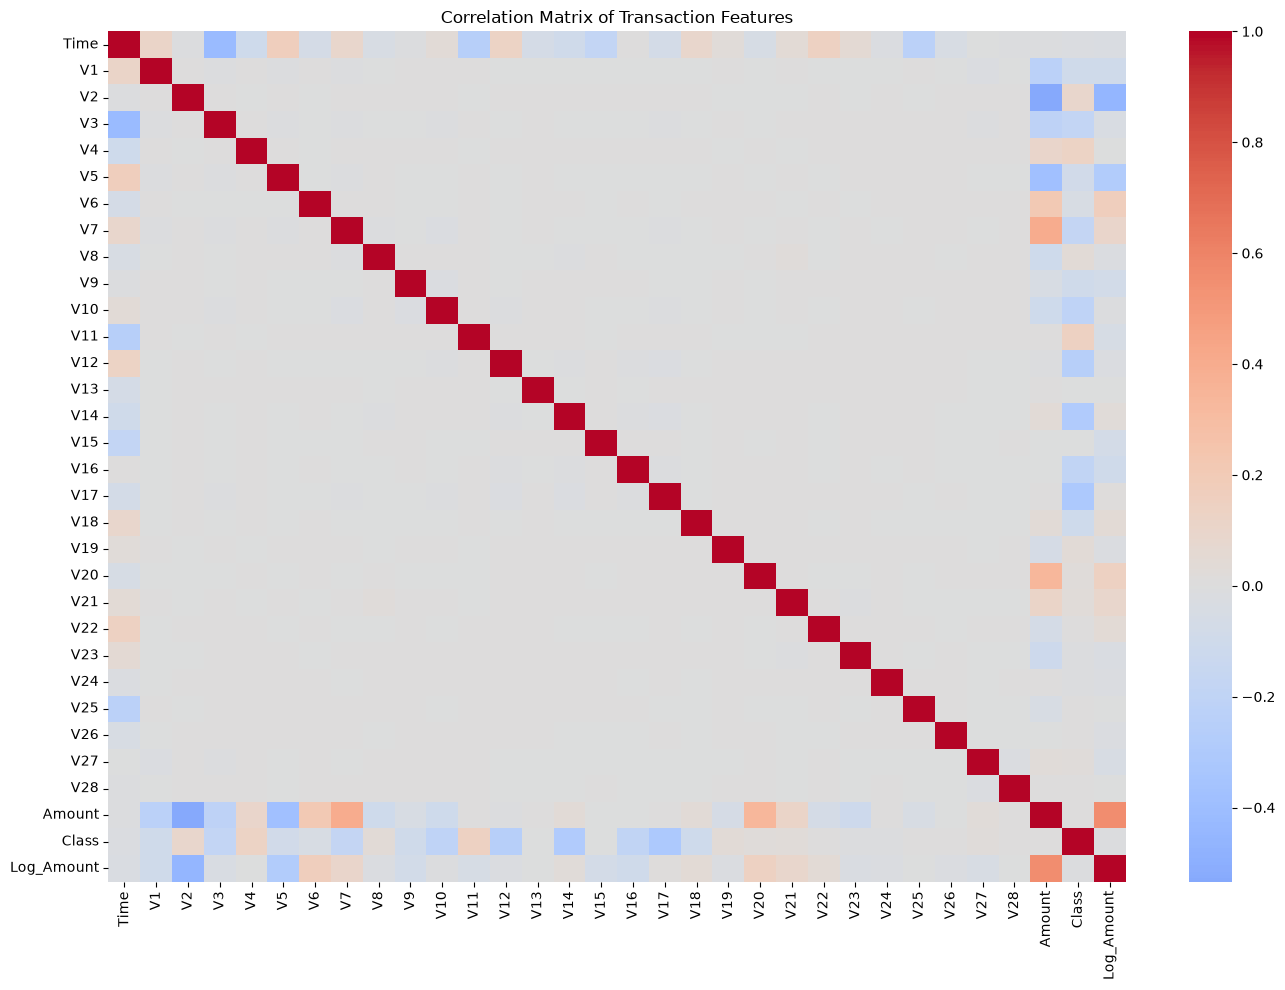

In [36]:
plt.figure(figsize=(14, 10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Transaction Features")

plt.tight_layout()
plt.show()

In [37]:
class_corr = df.corr(numeric_only=True)["Class"].sort_values()

class_corr

V17          -0.313498
V14          -0.293375
V12          -0.250711
V10          -0.206971
V16          -0.187186
V3           -0.182322
V7           -0.172347
V18          -0.105340
V1           -0.094486
V9           -0.094021
V5           -0.087812
V6           -0.043915
Time         -0.012359
Log_Amount   -0.007798
V24          -0.007210
V23          -0.006333
V13          -0.003897
V15          -0.003300
V25           0.003202
V26           0.004265
V22           0.004887
Amount        0.005777
V28           0.009682
V20           0.021486
V27           0.021892
V21           0.026357
V8            0.033068
V19           0.033631
V2            0.084624
V4            0.129326
V11           0.149067
Class         1.000000
Name: Class, dtype: float64

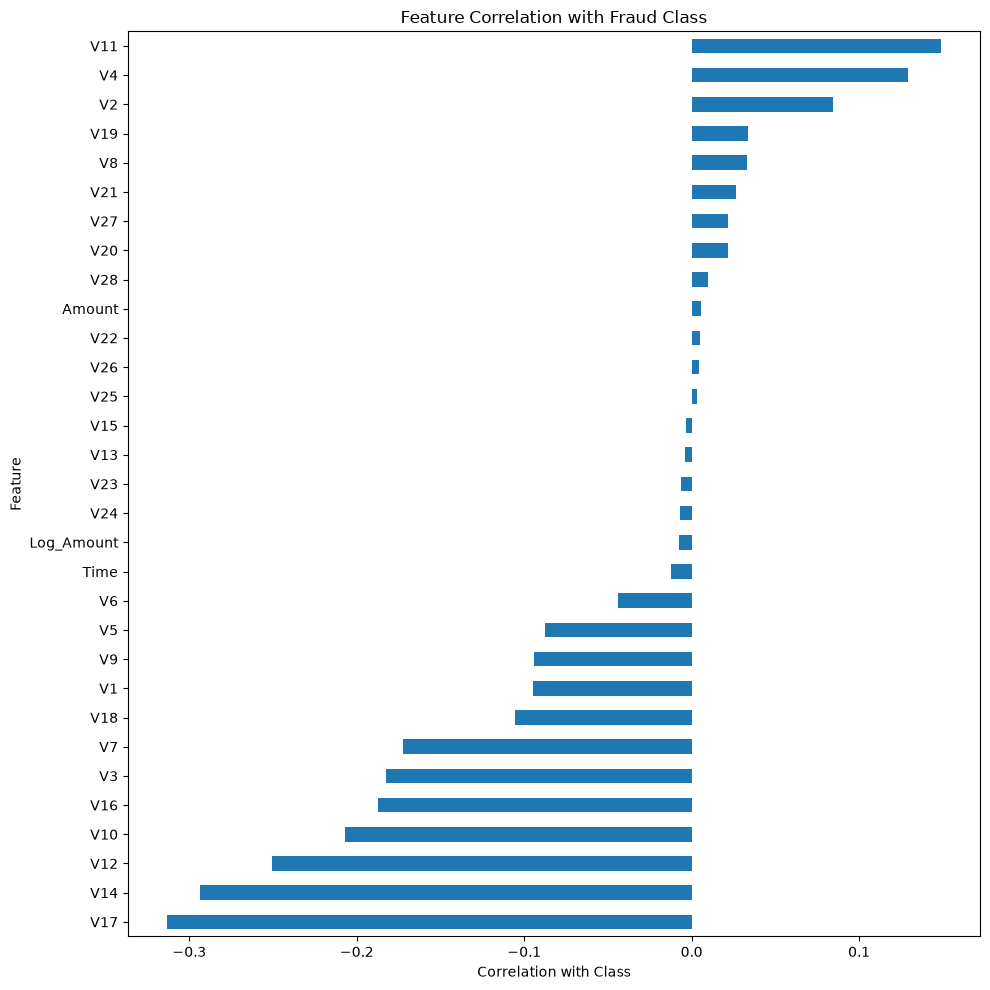

In [38]:
class_corr.drop("Class").sort_values().plot(
    kind="barh",
    figsize=(10, 10)
)

plt.title("Feature Correlation with Fraud Class")
plt.xlabel("Correlation with Class")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [39]:
class_corr.drop("Class").abs().sort_values(ascending=False).head(10)

V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
V3     0.182322
V7     0.172347
V11    0.149067
V4     0.129326
V18    0.105340
Name: Class, dtype: float64

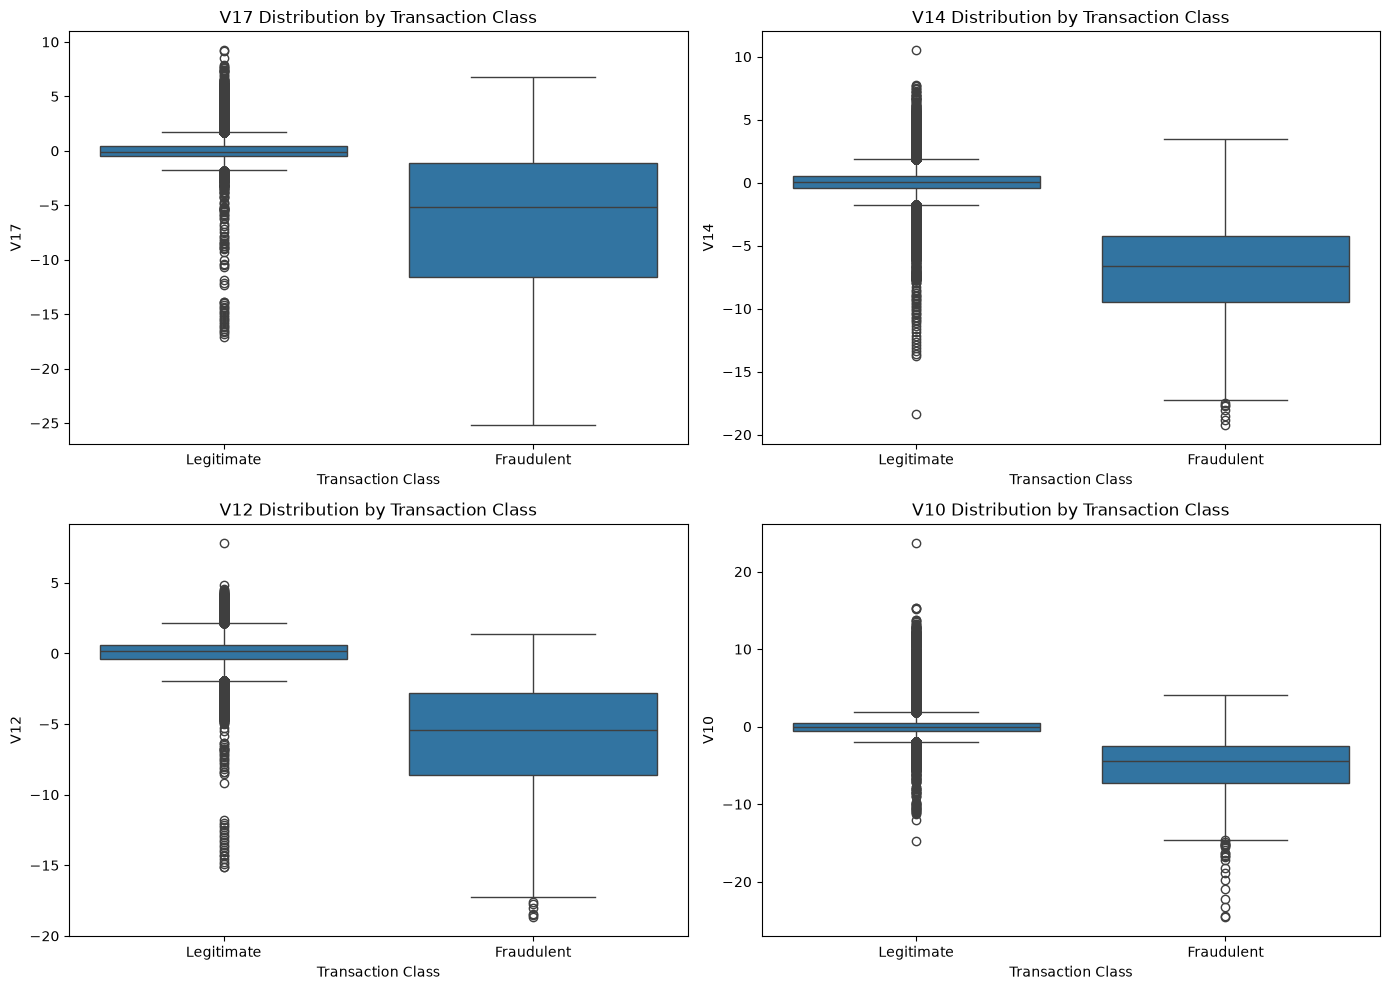

In [40]:
top_features = ["V17", "V14", "V12", "V10"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for feature, ax in zip(top_features, axes.flatten()):
    sns.boxplot(
        data=df,
        x="Class",
        y=feature,
        ax=ax
    )
    
    ax.set_title(f"{feature} Distribution by Transaction Class")
    ax.set_xlabel("Transaction Class")
    ax.set_ylabel(feature)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Legitimate", "Fraudulent"])

plt.tight_layout()
plt.show()

In [41]:
df["Log_Amount"] = np.log1p(df["Amount"])

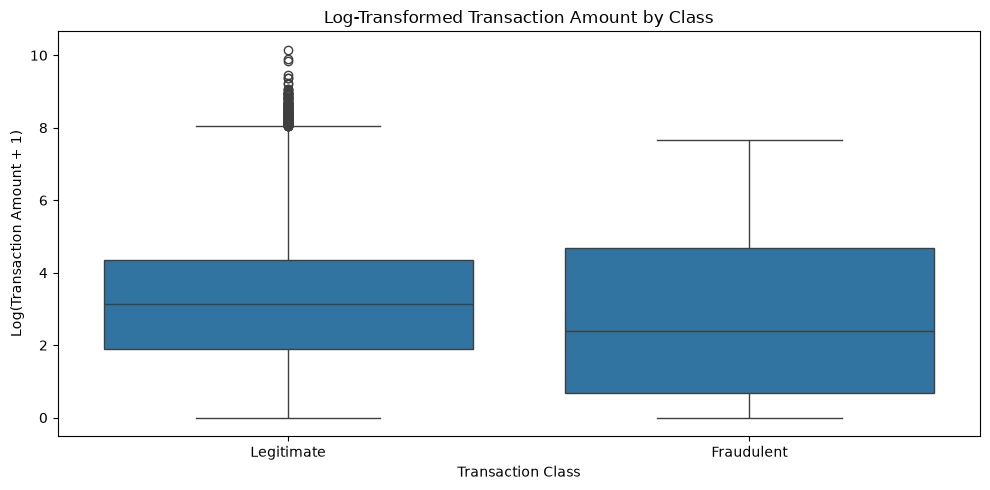

In [42]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Log_Amount"
)

plt.title("Log-Transformed Transaction Amount by Class")
plt.xlabel("Transaction Class")
plt.ylabel("Log(Transaction Amount + 1)")

plt.xticks([0, 1], ["Legitimate", "Fraudulent"])

plt.tight_layout()
plt.show()

In [43]:
df["Log_Amount"]

0         5.014760
1         1.305626
2         5.939276
3         4.824306
4         4.262539
            ...   
284802    0.570980
284803    3.249987
284804    4.232366
284805    2.397895
284806    5.384495
Name: Log_Amount, Length: 283726, dtype: float64

In [44]:
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Amount"] < lower_bound) |
    (df["Amount"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of outliers:", len(outliers))

Q1: 5.6
Q3: 77.51
IQR: 71.91000000000001
Lower Bound: -102.26500000000001
Upper Bound: 185.375
Number of outliers: 31685


In [45]:
outliers["Class"].value_counts()

Class
0    31598
1       87
Name: count, dtype: int64

In [46]:
pd.crosstab(
    outliers["Class"],
    columns="Count"
)

col_0,Count
Class,
0,31598
1,87


In [47]:
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Amount"] < lower_bound) |
    (df["Amount"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of outliers:", len(outliers))

Q1: 5.6
Q3: 77.51
IQR: 71.91000000000001
Lower Bound: -102.26500000000001
Upper Bound: 185.375
Number of outliers: 31685


In [48]:
outliers["Class"].value_counts()

Class
0    31598
1       87
Name: count, dtype: int64

In [49]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


In [50]:
df["Amount_Bin"] = pd.qcut(
    df["Amount"],
    q=5,
    duplicates="drop"
)

fraud_rate_by_amount = (
    df.groupby("Amount_Bin", observed=True)["Class"]
      .mean()
      .mul(100)
)

fraud_rate_by_amount

Amount_Bin
(-0.001, 3.58]       0.345656
(3.58, 13.04]        0.086729
(13.04, 37.07]       0.052859
(37.07, 100.0]       0.126137
(100.0, 25691.16]    0.221635
Name: Class, dtype: float64

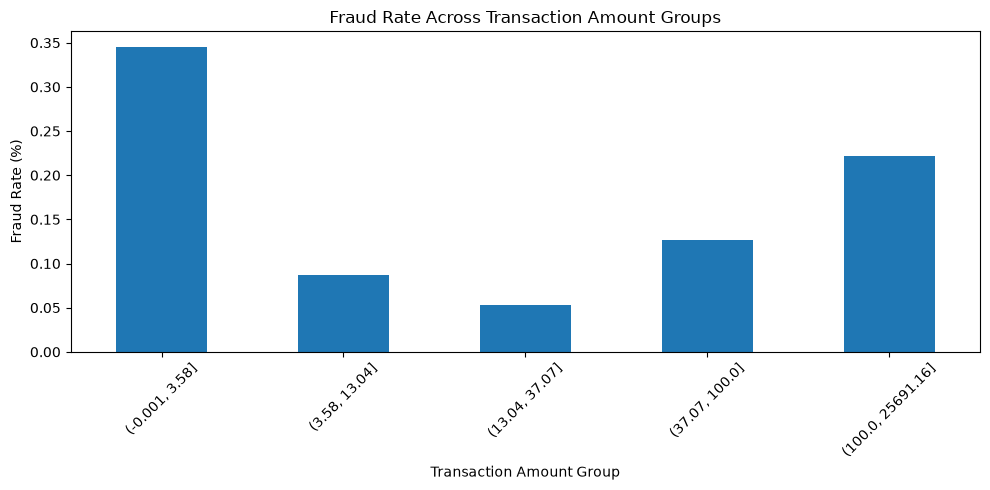

In [51]:
plt.figure(figsize=(10, 5))

fraud_rate_by_amount.plot(kind="bar")

plt.title("Fraud Rate Across Transaction Amount Groups")
plt.xlabel("Transaction Amount Group")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()